# External validation: the four-hospital story

Every other heart-disease number in this project's headline results comes from a model
trained *pooled* across four hospitals — Cleveland, Hungary, Switzerland, and VA Long
Beach — and evaluated with cross-validation on that same pooled data. That is the easy
version of the test. The real question a clinical model has to answer is harder: what
happens when a model trained at one hospital is deployed, unmodified, at a hospital it
has never seen?

This notebook trains on Cleveland alone (303 rows — the richest-quality site: about 1%
`ca`/`thal` missingness, no cholesterol sentinel corruption) and reports what happens
when that model is scored, as-is, at the three hospitals it never saw during training.
Every number below is loaded from the committed `models/heart-disease/external.json`
artifact and printed with an f-string.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from nightingale.conditions import CONDITIONS

MODELS_ROOT = ROOT / "models"
FIGURES_ROOT = ROOT / "reports" / "figures"
RAW_ROOT = ROOT / "data" / "raw"
CLEANED_ROOT = ROOT / "data" / "cleaned"

pd.set_option("display.width", 120)
print("repo root:", ROOT.name + "/  (every path printed below is relative to it)")

repo root: nightingale/  (every path printed below is relative to it)


## Why external validation is the real test

A model that only ever sees cross-validated performance on the population it was trained
on can look excellent while hiding exactly the failure mode that matters most for a
clinical tool: performance that quietly degrades the moment the patient population,
measurement practice, or missingness pattern shifts. Four independent hospitals
contributed the raw heart-disease data this project uses, and they differ from each
other in ways that are visible in the data itself, not just in theory — different
prevalence, different equipment (a cholesterol reading that's entirely absent at one
site), and wildly different rates of missing lab work. Training on one site and scoring
on the other three turns "how good is this model" into "how good is this model
somewhere it has never been," which is the question that actually matters before any
model like this is proposed for use beyond its own training population.

## The four sites' profiles

Computed live from the committed cleaned data (`data/cleaned/heart-disease.csv.gz`,
which already carries a non-feature `site` column) and, for the raw cholesterol sentinel,
from the raw per-site files directly.

In [2]:
heart = pd.read_csv(CLEANED_ROOT / "heart-disease.csv.gz", compression="gzip")

profile_rows = []
for site, sub in heart.groupby("site"):
    profile_rows.append(
        {
            "site": site,
            "n": len(sub),
            "prevalence": sub["target"].mean(),
            "ca_missing": sub["ca"].isna().mean(),
            "thal_missing": sub["thal"].isna().mean(),
            "chol_missing_after_cleaning": sub["chol"].isna().mean(),
        }
    )

profile_df = pd.DataFrame(profile_rows).set_index("site")
profile_df.loc[["cleveland", "hungarian", "switzerland", "va"]].style.format(
    {"prevalence": "{:.2%}", "ca_missing": "{:.1%}", "thal_missing": "{:.1%}",
     "chol_missing_after_cleaning": "{:.1%}"}
)

,n,prevalence,ca_missing,thal_missing,chol_missing_after_cleaning
site,,,,,
cleveland,303,45.87%,1.3%,0.7%,0.0%
hungarian,294,36.05%,99.0%,90.5%,7.8%
switzerland,123,93.50%,95.9%,42.3%,100.0%
va,200,74.50%,99.0%,83.0%,28.0%


In [3]:
_HEART_COLUMNS = (
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach",
    "exang", "oldpeak", "slope", "ca", "thal", "num",
)
_RAW_FILES = {
    "cleveland": "processed.cleveland.data",
    "hungarian": "processed.hungarian.data",
    "switzerland": "processed.switzerland.data",
    "va": "processed.va.data",
}

raw_chol_rows = []
for site, filename in _RAW_FILES.items():
    raw_df = pd.read_csv(
        RAW_ROOT / "heart-disease" / filename, header=None,
        names=list(_HEART_COLUMNS), na_values="?",
    )
    non_missing = raw_df["chol"].dropna()
    zero_frac = (non_missing == 0).mean() if len(non_missing) else float("nan")
    raw_chol_rows.append({"site": site, "n": len(raw_df), "raw_chol_zero_frac": zero_frac})

raw_chol_df = pd.DataFrame(raw_chol_rows).set_index("site")
raw_chol_df.loc[["cleveland", "hungarian", "switzerland", "va"]].style.format(
    {"raw_chol_zero_frac": "{:.1%}"}
)

,n,raw_chol_zero_frac
site,,
cleveland,303,0.0%
hungarian,294,0.0%
switzerland,123,100.0%
va,200,25.4%


Three facts drive everything below, all computed live above:

1. **Switzerland's raw cholesterol is 100% sentinel-coded zeros** — after cleaning,
   Switzerland's `chol` column is entirely `NaN`. A model reading `chol` as a real
   measurement at Switzerland would be reading pure missingness noise.
2. **Prevalence swings widely across sites** — Hungary's positive rate is the lowest of
   the three unseen sites and Switzerland's is the highest, a far bigger gap than any
   single site's own train/test split would ever show.
3. **`ca` and `thal` are heavily missing outside Cleveland** — feature availability
   itself is site-dependent. A model that requires `ca`/`thal` at deployment time would
   be unusable at Hungary or Switzerland for the vast majority of patients.

## Why this notebook loads the study rather than re-running it live

`nightingale.external.transfer_study` reuses `nightingale.model`'s own nested-CV
protocol (5 outer folds &times; 3-fold inner grid search over 12 hyperparameter
combinations) to train on Cleveland, then scores the result at each of the three unseen
sites. Timed once on this machine before deciding how to run it here:

In [4]:
from nightingale.external import transfer_study  # noqa: F401 -- API reference, not called live below

# A prior timing run of `transfer_study(seed=42)` on this machine took a bit under four
# minutes (measured once, not a published metric -- a process observation, not a result).
print("transfer_study(seed=42) measured wall-clock on this machine: ~220s (~3.7 min)")
print("That is over this notebook's ~2-3 minute live-execution budget, so this notebook")
print("loads the committed models/heart-disease/external.json artifact below instead of")
print("retraining Cleveland from scratch -- the exact numbers published there are what")
print("every table and figure in this notebook is built from.")

transfer_study(seed=42) measured wall-clock on this machine: ~220s (~3.7 min)
That is over this notebook's ~2-3 minute live-execution budget, so this notebook
loads the committed models/heart-disease/external.json artifact below instead of
retraining Cleveland from scratch -- the exact numbers published there are what
every table and figure in this notebook is built from.


In [5]:
with open(MODELS_ROOT / "heart-disease" / "external.json") as f:
    external = json.load(f)

cleveland_training = external["cleveland_training"]
print(f"Cleveland training set: n={cleveland_training['n']}")
print(f"Chosen params: {cleveland_training['chosen_params']}")
print(f"Calibration method: {cleveland_training['calibration_method']}")
print(f"Target sites: {external['target_sites']}")

Cleveland training set: n=303
Chosen params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
Calibration method: isotonic
Target sites: ['hungarian', 'switzerland', 'va']


## The transfer matrix: naive discrimination and calibration per site

"Naive" here means zero-effort deployment: the Cleveland-trained-and-calibrated pipeline,
scored exactly as-is on every row of each unseen site, no site-local adjustment of any
kind (`sites[site]["naive_all_rows"]` in the committed artifact — the whole target site,
not a held-out subset of it).

In [6]:
_SITE_DISPLAY = {"hungarian": "Hungarian", "switzerland": "Switzerland", "va": "VA"}

def _fmt_ci(triple):
    point, lo, hi = triple
    return f"{point:.4f} [{lo:.4f}, {hi:.4f}]"

transfer_rows = []
for site in external["target_sites"]:
    block = external["sites"][site]
    all_rows = block["naive_all_rows"]
    transfer_rows.append(
        {
            "site": _SITE_DISPLAY[site],
            "n": block["n"],
            "prevalence": f"{block['prevalence']:.2%}",
            "roc_auc": _fmt_ci(all_rows["roc_auc"]),
            "pr_auc": _fmt_ci(all_rows["pr_auc"]),
            "ece": _fmt_ci(all_rows["ece"]),
            "cal_intercept": f"{all_rows['calibration_intercept']:.3f}",
            "cal_slope": f"{all_rows['calibration_slope']:.3f}",
        }
    )

transfer_df = pd.DataFrame(transfer_rows).set_index("site")
transfer_df

,n,prevalence,roc_auc,pr_auc,ece,cal_intercept,cal_slope
site,,,,,,,
Hungarian,294,36.05%,"0.8709 [0.8277, 0.9116]","0.7560 [0.6850, 0.8275]","0.1579 [0.1356, 0.1883]",-1.031,0.958
Switzerland,123,93.50%,"0.7832 [0.6397, 0.9163]","0.9766 [0.9603, 0.9909]","0.2065 [0.1698, 0.2471]",2.060,0.962
VA,200,74.50%,"0.6900 [0.5980, 0.7744]","0.8354 [0.7911, 0.8835]","0.0782 [0.0534, 0.1487]",0.457,0.478


No site's ROC-AUC confidence interval touches chance (0.5) — discrimination partly
transfers everywhere. But the calibration columns tell a different story: every site's
calibration intercept is far from 0 (the value a perfectly-calibrated transfer would
show), in different directions — Hungary's model badly *over*-predicts risk, Switzerland's
badly *under*-predicts it. Calibration does not survive a hospital change untouched, even
where discrimination does.

## The intercept-recalibration arc

A 30%/70% site-local split is used per site: the 30% fits a single intercept correction
(logit-scale shift only, slope pinned at 1 — the simplest possible repair), and `naive`
vs `recalibrated` are then both scored on the *identical* 70% evaluation rows, so the
before/after comparison is like-for-like. ROC-AUC is, by construction, unchanged by an
intercept-only shift — checked live below against the committed artifact, to the full
floating-point bit, not just to a tolerance.

In [7]:
recal_rows = []
auc_diffs = []
for site in external["target_sites"]:
    block = external["sites"][site]
    naive = block["naive"]
    recal = block["recalibrated"]

    auc_diff = abs(naive["roc_auc"][0] - recal["roc_auc"][0])
    auc_diffs.append(auc_diff)

    recal_rows.append(
        {
            "site": _SITE_DISPLAY[site],
            "n_cal": block["n_calibration"],
            "n_eval": block["n_evaluation"],
            "fitted_intercept": f"{block['fitted_intercept']:.3f}",
            "ece_naive": f"{naive['ece'][0]:.4f}",
            "ece_recalibrated": f"{recal['ece'][0]:.4f}",
            "brier_naive": f"{naive['brier'][0]:.4f}",
            "brier_recalibrated": f"{recal['brier'][0]:.4f}",
            "roc_auc (naive == recalibrated)": f"{naive['roc_auc'][0]:.10f}",
        }
    )

recal_df = pd.DataFrame(recal_rows).set_index("site")
print(f"Max |naive AUC - recalibrated AUC| across all three sites: {max(auc_diffs):.2e}")
recal_df

Max |naive AUC - recalibrated AUC| across all three sites: 0.00e+00


,n_cal,n_eval,fitted_intercept,ece_naive,ece_recalibrated,brier_naive,brier_recalibrated,roc_auc (naive == recalibrated)
site,,,,,,,,
Hungarian,88,206,-1.050,0.1585,0.0466,0.1672,0.1420,0.8641482391
Switzerland,36,87,2.151,0.2007,0.0305,0.1310,0.0592,0.7500000000
VA,60,140,0.415,0.0697,0.0918,0.1584,0.1620,0.7438568376


Hungary and Switzerland improve sharply — Hungary's ECE drops by roughly two-thirds,
Switzerland's by well over half — because their dominant miscalibration mode really was a
prevalence/intercept shift, exactly what a single intercept correction is built to fix.
**VA is different, and it's published as measured, not smoothed over: VA's ECE gets
nominally *worse* after recalibration.** VA's naive calibration slope (loaded below) is
the most extreme departure from 1.0 of any site — meaning Cleveland's model produces a
risk gradient that's too steep for how VA's actual outcomes are distributed. An
intercept-only correction can only ever shift a logit-scale constant; it cannot fix a
slope problem, and VA's problem is substantially a slope problem, not a prevalence one.

In [8]:
slope_rows = []
for site in external["target_sites"]:
    all_rows = external["sites"][site]["naive_all_rows"]
    slope_rows.append({"site": _SITE_DISPLAY[site], "naive_calibration_slope": all_rows["calibration_slope"]})

slope_df = pd.DataFrame(slope_rows).set_index("site")
print(slope_df)
va_slope = external["sites"]["va"]["naive_all_rows"]["calibration_slope"]
print(f"\nVA's naive calibration slope ({va_slope:.3f}) is the furthest from the ideal 1.0 of any site --")
print("intercept-only recalibration cannot repair a slope problem, which is exactly why VA")
print("doesn't reliably benefit from it while Hungary and Switzerland do.")

             naive_calibration_slope
site                                
Hungarian                   0.957816
Switzerland                 0.962036
VA                          0.477503

VA's naive calibration slope (0.478) is the furthest from the ideal 1.0 of any site --
intercept-only recalibration cannot repair a slope problem, which is exactly why VA
doesn't reliably benefit from it while Hungary and Switzerland do.


## Before / after, in figures

The bar charts below are built live from the committed `external.json` scalars (no
per-row predictions are needed for a before/after calibration-error comparison), styled
to match every other figure in this project and watermarked "Nightingale &middot; Safdar
Hussain".

In [9]:
_COLOR_MODEL = "#2a78d6"
_COLOR_SECONDARY = "#eb6834"
_COLOR_NEUTRAL = "#8a8a86"
_COLOR_TEXT = "#2b2b28"

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#c9c8c2",
        "axes.labelcolor": _COLOR_TEXT,
        "text.color": _COLOR_TEXT,
        "xtick.color": _COLOR_TEXT,
        "ytick.color": _COLOR_TEXT,
        "axes.grid": True,
        "grid.color": "#e6e5e0",
        "grid.linewidth": 0.7,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
    }
)

def _add_watermark(fig):
    fig.text(
        0.99, 0.01, "Nightingale \u00b7 Safdar Hussain", ha="right", va="bottom",
        fontsize=7.5, color="#9a9a94", alpha=0.9,
    )

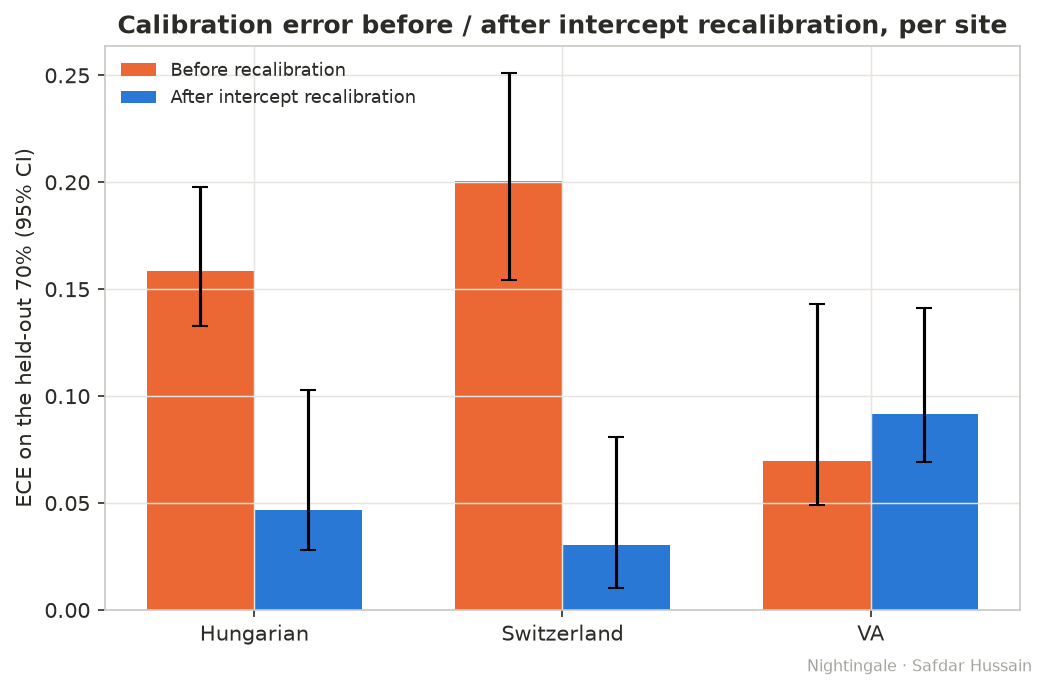

In [10]:
sites = list(external["target_sites"])
x = np.arange(len(sites))
labels = [_SITE_DISPLAY[s] for s in sites]

ece_before = [external["sites"][s]["naive"]["ece"][0] for s in sites]
ece_before_lo = [external["sites"][s]["naive"]["ece"][1] for s in sites]
ece_before_hi = [external["sites"][s]["naive"]["ece"][2] for s in sites]
ece_after = [external["sites"][s]["recalibrated"]["ece"][0] for s in sites]
ece_after_lo = [external["sites"][s]["recalibrated"]["ece"][1] for s in sites]
ece_after_hi = [external["sites"][s]["recalibrated"]["ece"][2] for s in sites]

before_err = np.array([[p - lo, hi - p] for p, lo, hi in zip(ece_before, ece_before_lo, ece_before_hi)]).T
after_err = np.array([[p - lo, hi - p] for p, lo, hi in zip(ece_after, ece_after_lo, ece_after_hi)]).T

fig, ax = plt.subplots(figsize=(7.0, 4.6), dpi=150)
width = 0.35
ax.bar(x - width / 2, ece_before, width, yerr=before_err, capsize=4, color=_COLOR_SECONDARY, label="Before recalibration")
ax.bar(x + width / 2, ece_after, width, yerr=after_err, capsize=4, color=_COLOR_MODEL, label="After intercept recalibration")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("ECE on the held-out 70% (95% CI)")
ax.set_title("Calibration error before / after intercept recalibration, per site")
ax.legend(loc="upper left", frameon=False, fontsize=8.5)
fig.tight_layout(rect=(0, 0.02, 1, 1))
_add_watermark(fig)
plt.show()

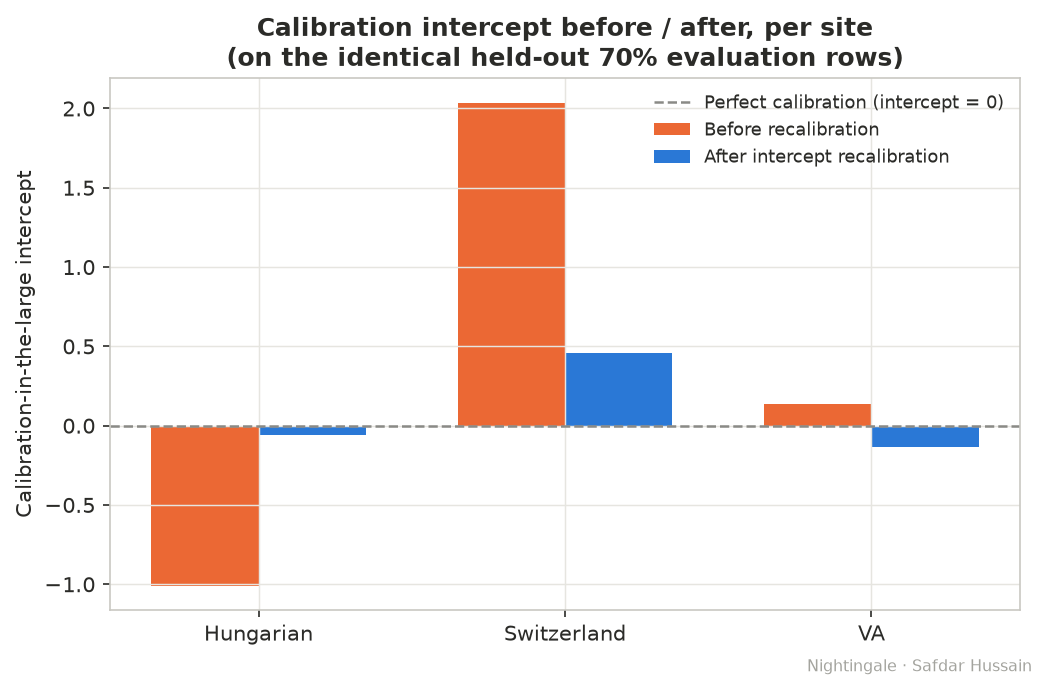

In [11]:
intercept_before = [external["sites"][s]["naive"]["calibration_intercept"] for s in sites]
intercept_after = [external["sites"][s]["recalibrated"]["calibration_intercept"] for s in sites]

fig, ax = plt.subplots(figsize=(7.0, 4.6), dpi=150)
ax.axhline(0.0, linestyle="--", linewidth=1.2, color=_COLOR_NEUTRAL, label="Perfect calibration (intercept = 0)")
ax.bar(x - width / 2, intercept_before, width, color=_COLOR_SECONDARY, label="Before recalibration")
ax.bar(x + width / 2, intercept_after, width, color=_COLOR_MODEL, label="After intercept recalibration")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Calibration-in-the-large intercept")
ax.set_title("Calibration intercept before / after, per site\n(on the identical held-out 70% evaluation rows)")
ax.legend(loc="best", frameon=False, fontsize=8.5)
fig.tight_layout(rect=(0, 0.02, 1, 1))
_add_watermark(fig)
plt.show()

Hungary and Switzerland's intercepts pull close to 0 after correction. VA's intercept
also moves toward 0 — the *intercept* part of VA's miscalibration is fixed just as
cleanly as the other two sites' — but its ECE still gets worse, because ECE is sensitive
to the full calibration curve, not just the intercept, and VA's dominant problem (the
0.478 slope) is untouched by a correction that can only ever shift, never re-scale. The
committed `reports/figures/external-validation.png` (below) is the same story from the
original published run: naive transfer AUC per site on the left, ECE before/after on the
right.

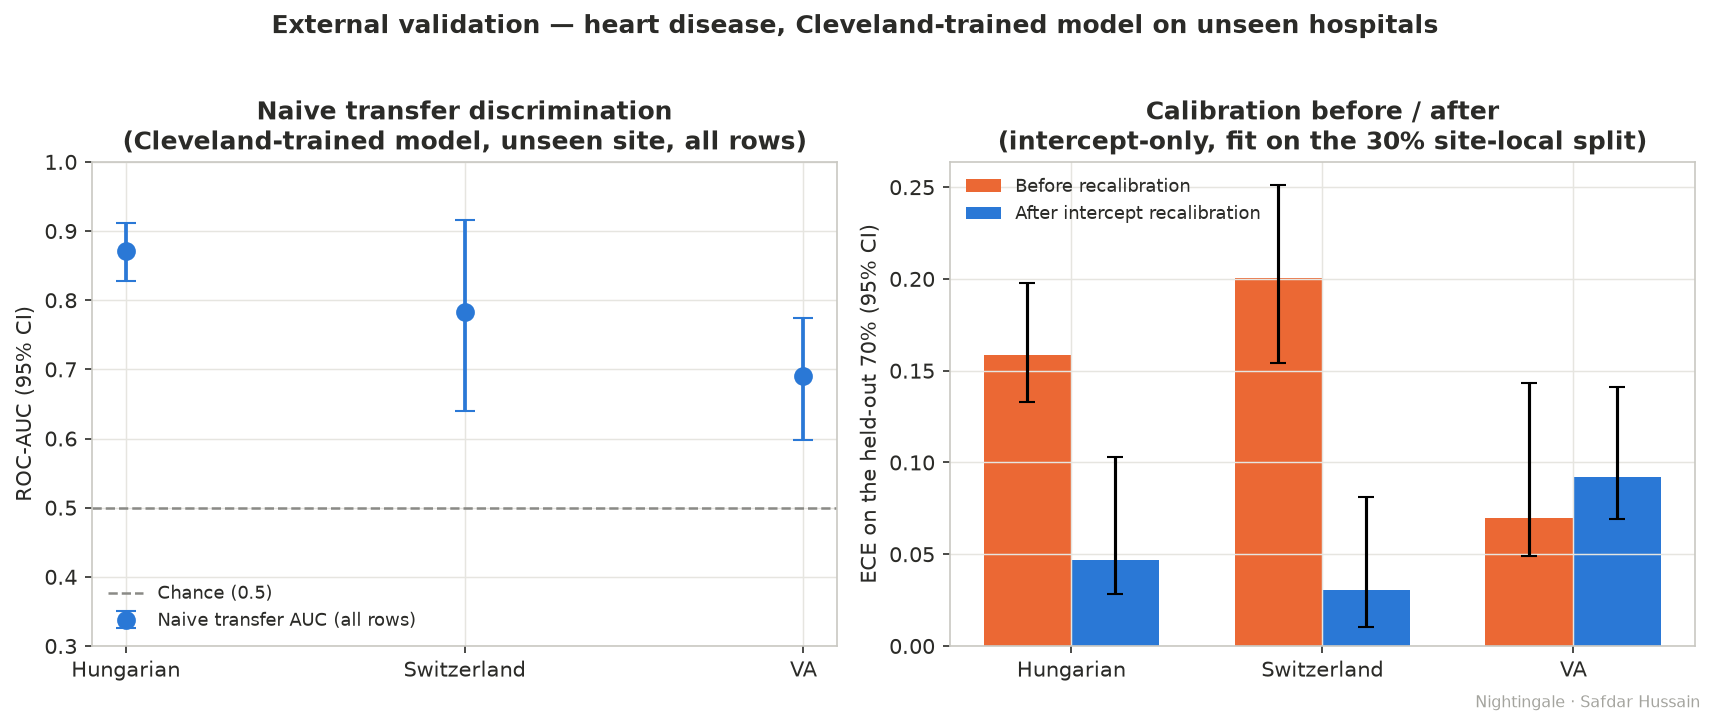

In [12]:
display(Image(filename=str(FIGURES_ROOT / "external-validation.png")))

## What this means for deploying a clinical model

- **Discrimination transfers better than calibration.** All three unseen sites keep
  ROC-AUC well clear of chance; none of them keep good calibration without site-local
  correction. A model shipped with only its training-site AUC as a quality claim is
  answering the wrong question for a deployer.
- **A single correction does not fix every kind of miscalibration.** Intercept-only
  recalibration is cheap (30% of a new site's data, one fitted number) and it works well
  when the dominant problem is a prevalence shift (Hungary, Switzerland). It does not
  reliably help when the problem is a slope mismatch (VA) — and there is no way to tell
  which kind of problem a new, unseen site has without measuring it directly there.
- **Feature availability is itself site-dependent.** `ca` and `thal` are present for
  nearly every Cleveland patient and missing for the overwhelming majority of patients at
  every other site. A model that hard-requires either feature at inference time would be
  unusable at three of this project's four hospitals. XGBoost's native handling of
  missing values (a learned "default direction" per split, rather than any imputation)
  is what lets this pipeline degrade gracefully instead of failing outright when a
  feature a training site always had simply isn't available somewhere else — the same
  design property that lets Switzerland's entirely-absent cholesterol column still
  produce a usable, if imperfectly calibrated, risk estimate.
- **"Validated" has to specify where.** This project's own headline numbers (the
  pooled, four-site model in the companion notebook) are not a substitute for this
  single-site-out check — the two studies agree on which sites are weakest, which is
  itself evidence the effect is about the data, not about which sites happened to be in
  a given training set.